In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [10]:
df_semfalha = pd.read_excel('../datasetventoinha/Ventoinha de corrente contínua_Sem anomalias_Arduino.xlsx')

df_semfalha['classificacao'] = 'sem falha'

df_semfalha.info()
df_semfalha.head()

<class 'pandas.DataFrame'>
RangeIndex: 20299 entries, 0 to 20298
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       20299 non-null  int64  
 1   Ax_g           20299 non-null  float64
 2   Ay_g           20299 non-null  float64
 3   Az_g           20299 non-null  float64
 4   Vibracao_g     20299 non-null  float64
 5   classificacao  20299 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 951.6 KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,0.0337,-0.0396,-1.0854,0.0867,sem falha
1,3,0.0488,-0.0278,-1.0464,0.0479,sem falha
2,6,0.0537,-0.0107,-1.0269,0.0283,sem falha
3,9,0.0288,-0.0146,-0.9639,0.0356,sem falha
4,11,0.0332,-0.0229,-1.0249,0.0257,sem falha


In [11]:
df_falha_parcial = pd.read_excel('../datasetventoinha/Ventoinha de corrente contínua_Falha na pa parcial_umquarto_Arduino.xlsx')

df_falha_parcial['classificacao'] = 'falha parcial'

df_falha_parcial.info()
df_falha_parcial.head()


# excel_file = pd.ExcelFile('../datasetventoinha/falha total_features_ventilador.xlsx')
# print("Abas encontradas:", excel_file.sheet_names)

# df_window_falhaparcial = pd.read_excel('../datasetventoinha/umquarto_parcialfeatures_ventilador.xlsx', sheet_name='Features_por_Janela')
# df_window_falhaparcial.info()

# df_window_falhaparcial.head()

<class 'pandas.DataFrame'>
RangeIndex: 20274 entries, 0 to 20273
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       20274 non-null  int64  
 1   Ax_g           20274 non-null  float64
 2   Ay_g           20274 non-null  float64
 3   Az_g           20274 non-null  float64
 4   Vibracao_g     20274 non-null  float64
 5   classificacao  20274 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 950.5 KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,0.1475,-0.0308,-1.0444,0.0552,falha parcial
1,4,0.2202,0.0029,-0.9570,0.0180,falha parcial
2,7,-0.0215,0.0850,-0.9448,0.0511,falha parcial
3,9,-0.0859,0.0059,-1.1343,0.1375,falha parcial
4,12,-0.0557,-0.0562,-1.1260,0.1287,falha parcial


In [12]:
df_falha_total = pd.read_excel('../datasetventoinha/Ventoinha de corrente contínua_Falha na pa total_Arduino.xlsx')


df_falha_total['classificacao'] = 'falha total'

df_falha_total.info()
df_falha_total.head()

# excel_file = pd.ExcelFile('../datasetventoinha/falha total_features_ventilador.xlsx')
# print("Abas encontradas:", excel_file.sheet_names)

# df_window_semfalha = pd.read_excel('../datasetventoinha/falha total_features_ventilador.xlsx', sheet_name='Features_por_Janela')
# df_window_semfalha.info()

# df_window_semfalha.head()

<class 'pandas.DataFrame'>
RangeIndex: 20250 entries, 0 to 20249
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       20250 non-null  int64  
 1   Ax_g           20250 non-null  float64
 2   Ay_g           20250 non-null  float64
 3   Az_g           20250 non-null  float64
 4   Vibracao_g     20250 non-null  float64
 5   classificacao  20250 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 949.3 KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,0.0439,0.0752,-0.9287,0.0672,falha total
1,3,-0.1479,0.0068,-1.0898,0.0999,falha total
2,6,-0.0361,-0.0972,-1.1157,0.1205,falha total
3,8,0.1577,-0.1021,-1.0771,0.0934,falha total
4,11,0.2256,0.0337,-0.9624,0.0109,falha total


In [14]:
tamanho_janela_ms = 30

# Usa 'Tempo_ms' em vez de 'Tempo'
df_unificado['ID_Janela'] = (df_unificado['Tempo_ms'] // tamanho_janela_ms).astype(int)

# Usa 'Ax_g', 'Ay_g', 'Az_g'
df_features = df_unificado.groupby(['classificacao', 'ID_Janela']).agg(
    Ax_Mean=('Ax_g', 'mean'),
    Ax_Std=('Ax_g', 'std'),
    Ax_Max=('Ax_g', 'max'),
    Ax_Min=('Ax_g', 'min'),
    Ay_Mean=('Ay_g', 'mean'),
    Ay_Std=('Ay_g', 'std'),
    Ay_Max=('Ay_g', 'max'),
    Ay_Min=('Ay_g', 'min'),
    Az_Mean=('Az_g', 'mean'),
    Az_Std=('Az_g', 'std'),
    Az_Max=('Az_g', 'max'),
    Az_Min=('Az_g', 'min')
).reset_index()

df_features = df_features.dropna().reset_index(drop=True)

print("Dimensão do dataset final:", df_features.shape)
df_features.head()

Dimensão do dataset final: (6000, 14)


,classificacao,ID_Janela,Ax_Mean,Ax_Std,Ax_Max,Ax_Min,Ay_Mean,Ay_Std,Ay_Max,Ay_Min,Az_Mean,Az_Std,Az_Max,Az_Min
0,falha parcial,0,0.047318,0.109448,0.2202,-0.0859,-0.002755,0.062793,0.0986,-0.1064,-1.041145,0.059951,-0.9448,-1.1343
1,falha parcial,1,0.033700,0.106366,0.2026,-0.0698,0.004630,0.043414,0.0781,-0.0669,-1.053020,0.060457,-0.9585,-1.1772
2,falha parcial,2,0.036318,0.097474,0.2139,-0.0913,-0.007100,0.065842,0.1021,-0.0981,-1.047936,0.053269,-0.9604,-1.1455
3,falha parcial,3,0.035445,0.113940,0.2109,-0.0923,-0.007591,0.061886,0.0908,-0.1030,-1.050200,0.077615,-0.9214,-1.1641
4,falha parcial,4,0.017530,0.070280,0.1318,-0.0742,0.007370,0.054421,0.0688,-0.1094,-1.045990,0.048818,-0.9619,-1.1206


Acurácia Total: 100.00%

Relatório de Classificação:

               precision    recall  f1-score   support

falha parcial       1.00      1.00      1.00       400
  falha total       1.00      1.00      1.00       400
    sem falha       1.00      1.00      1.00       400

     accuracy                           1.00      1200
    macro avg       1.00      1.00      1.00      1200
 weighted avg       1.00      1.00      1.00      1200



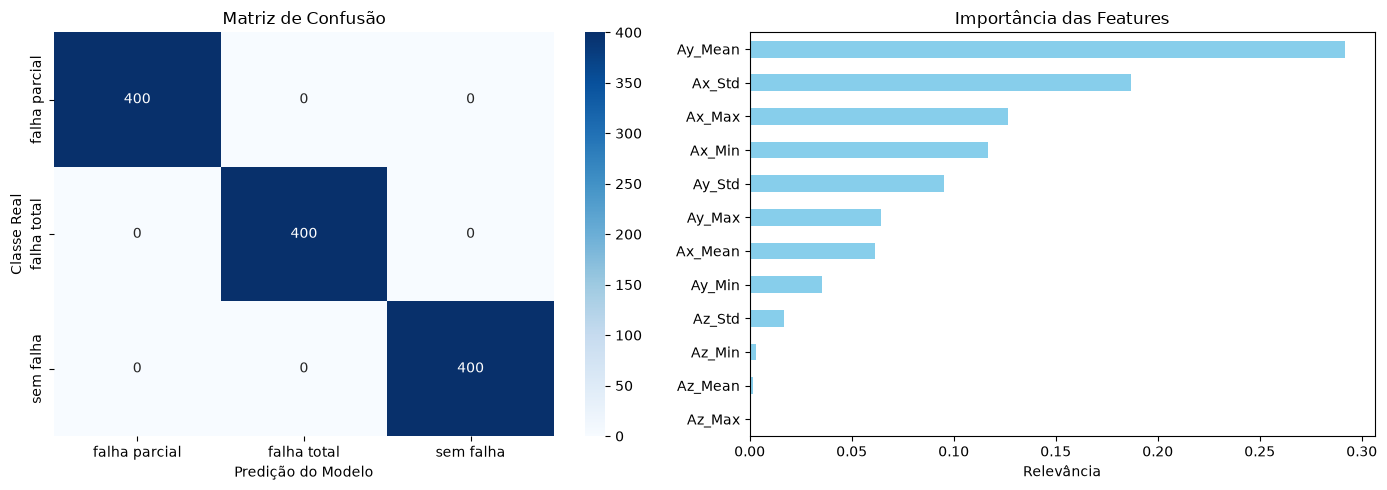

In [ ]:
# 1. Separar as variáveis preditoras (X) do rótulo/alvo (y)
X = df_features.drop(columns=['classificacao', 'ID_Janela'])
y = df_features['classificacao']

# 2. Divisão em Treino (80%) e Teste (20%) com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Inicializar e treinar o Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=67)
rf_model.fit(X_train, y_train)

# 4. Fazer predições no conjunto de teste
y_pred = rf_model.predict(X_test)

# 5. Avaliação do Desempenho
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia Total: {acc * 100:.2f}%\n")
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred))

# 6. Gráficos da Matriz de Confusão e Importância das Features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_, ax=axes[0])
axes[0].set_title('Matriz de Confusão')
axes[0].set_xlabel('Predição do Modelo')
axes[0].set_ylabel('Classe Real')

# Importância das Features
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='skyblue')
axes[1].set_title('Importância das Features')
axes[1].set_xlabel('Relevância')

plt.tight_layout()
plt.show()